In [ ]:
# Cell 1: Introduction and Setup

# This notebook optimizes a credit card fraud detection model for production
# Original model: https://www.kaggle.com/code/janiobachmann/credit-fraud-dealing-with-imbalanced-datasets
# Dataset: https://www.kaggle.com/mlg-ulb/creditcardfraud (upload creditcard.csv to Colab)

# Install required libraries
!pip install imbalanced-learn onnxmltools skl2onnx flask xgboost onnx onnxruntime -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from scipy.stats import ks_2samp
import pickle
import onnx
from onnxmltools.convert import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import time
import warnings
from sklearn.utils import resample
warnings.filterwarnings('ignore')

In [ ]:
# Cell 2: Load and Preprocess Data

# Load dataset (replace with actual path after uploading to Colab)
data = pd.read_csv('creditcard.csv')

# Check data summary and identify NaN values
print("Dataset Info:")
print(data.info())
print("\nNaN Values in Dataset:")
print(data.isnull().sum())  # Check for NaN in all columns
print("\nNaN Values in 'Class':", data['Class'].isnull().sum())  # Specific check for target
print("\nClass Distribution:")
print(data['Class'].value_counts(normalize=True))

# Handle NaN values in 'Class' by dropping rows with NaN
if data['Class'].isnull().sum() > 0:
    print(f"Dropping {data['Class'].isnull().sum()} rows with NaN in 'Class'")
    data = data.dropna(subset=['Class'])

# Split features and target
X = data.drop('Class', axis=1)
y = data['Class']

# Verify no NaN in y
print("\nNaN in y after dropping:", y.isnull().sum())  # Should be 0

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to handle imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Standardize features for Logistic Regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Save scaler for production use
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 


Random Forest Performance (Optimized):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.68      0.86      0.76        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.928228505104912
Tuning Time (on subset): 118.42 seconds
Final Training Time (on full data): 283.05 seconds
Inference Time per Transaction: 0.0045 ms


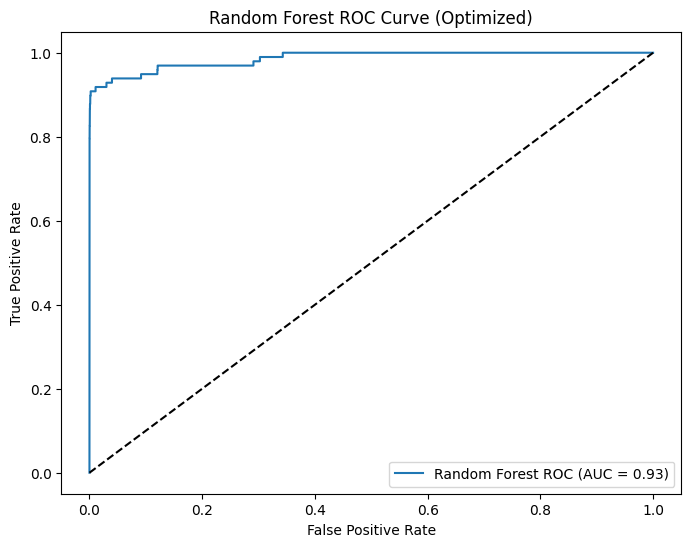

In [ ]:
# Cell 3: Train and Evaluate Random Forest (Optimized)



# Sample a subset of the SMOTE-balanced training data for hyperparameter tuning
# We'll use 20% of the data to speed up tuning, then train the final model on the full data
from sklearn.utils import resample
X_train_smote_subset, y_train_smote_subset = resample(
    X_train_smote, y_train_smote,
    n_samples=int(0.2 * len(X_train_smote)),  # 20% of the data
    random_state=42
)

# Initialize Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Define a smaller parameter grid for tuning
# - Fix class_weight='balanced' since SMOTE already balances the data
# - Reduce options for other parameters to speed up
rf_param_grid = {
    'n_estimators': [50],           # Reduced to one option (fewer trees)
    'max_depth': [10, 15],          # Slightly reduced range
    'min_samples_split': [5]        # Reduced to one option
}

# Perform grid search with reduced cross-validation folds (cv=2 instead of 3)
rf_grid = GridSearchCV(
    rf_model,
    rf_param_grid,
    cv=2,              # Reduced folds to speed up
    scoring='recall',  # Optimize for recall (catching fraud)
    n_jobs=-1          # Use all available CPU cores
)
start_time = time.time()
rf_grid.fit(X_train_smote_subset, y_train_smote_subset)
tuning_time = time.time() - start_time

# Best Random Forest model from tuning
rf_best = rf_grid.best_estimator_

# Train the best model on the full SMOTE-balanced training data
start_time = time.time()
rf_best.fit(X_train_smote, y_train_smote)  # Full data for final training
rf_training_time = time.time() - start_time

# Predict on the test set
y_pred_rf = rf_best.predict(X_test)

# Evaluate performance
print("\nRandom Forest Performance (Optimized):")
print(classification_report(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_rf))
print(f"Tuning Time (on subset): {tuning_time:.2f} seconds")
print(f"Final Training Time (on full data): {rf_training_time:.2f} seconds")

# Measure inference time
start_time = time.time()
y_pred_rf = rf_best.predict(X_test)
rf_inference_time = (time.time() - start_time) / len(X_test) * 1000  # ms per prediction
print(f"Inference Time per Transaction: {rf_inference_time:.4f} ms")

# Plot ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_best.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest ROC (AUC = {roc_auc_score(y_test, y_pred_rf):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve (Optimized)')
plt.legend()
plt.savefig('rf_roc_curve_optimized.png')
plt.show()


XGBoost Performance (Optimized):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.20      0.90      0.33        98

    accuracy                           0.99     56962
   macro avg       0.60      0.95      0.66     56962
weighted avg       1.00      0.99      1.00     56962

AUC-ROC: 0.9458581090004938
Tuning Time (on subset): 8.21 seconds
Final Training Time (on full data): 5.13 seconds
Inference Time per Transaction: 0.0011 ms


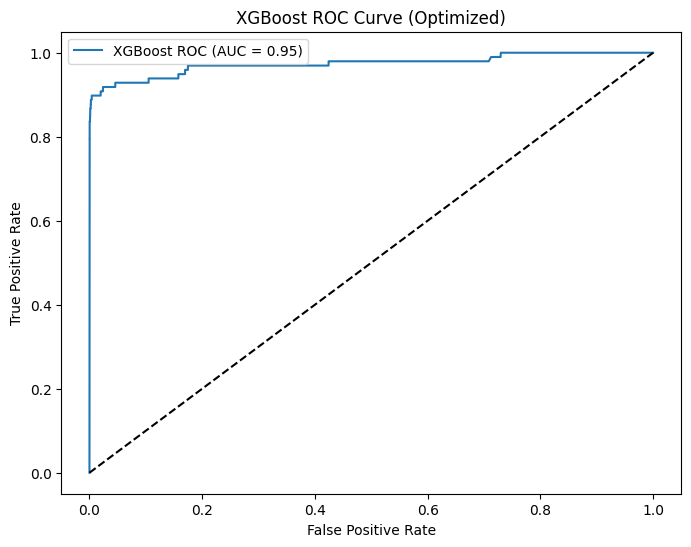

In [ ]:
# Cell 4: Train and Evaluate XGBoost (Optimized)

# Sample a subset of the SMOTE-balanced training data for hyperparameter tuning
X_train_smote_subset, y_train_smote_subset = resample(
    X_train_smote, y_train_smote,
    n_samples=int(0.2 * len(X_train_smote)),  # 20% of the data
    random_state=42
)

# Initialize XGBoost with optimized parameters
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist'  # Histogram-based method for faster training
)

# Define a smaller parameter grid for tuning
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])  # ~570:1
xgb_param_grid = {
    'n_estimators': [50],           # Fixed to minimize trees
    'max_depth': [3, 5],            # Reduced range
    'learning_rate': [0.1]          # Fixed to a reasonable value
}

# Perform grid search with reduced cross-validation folds
xgb_grid = GridSearchCV(
    xgb_model,
    xgb_param_grid,
    cv=2,              # Reduced to 2 folds
    scoring='recall',
    n_jobs=-1
)
start_time = time.time()
xgb_grid.fit(X_train_smote_subset, y_train_smote_subset)
tuning_time = time.time() - start_time

# Best XGBoost model from tuning
xgb_best = xgb_grid.best_estimator_

# Train the best model on the full SMOTE-balanced training data
start_time = time.time()
xgb_best.fit(X_train_smote, y_train_smote)
xgb_training_time = time.time() - start_time

# Predict on the test set
y_pred_xgb = xgb_best.predict(X_test)

# Evaluate performance
print("\nXGBoost Performance (Optimized):")
print(classification_report(y_test, y_pred_xgb))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_xgb))
print(f"Tuning Time (on subset): {tuning_time:.2f} seconds")
print(f"Final Training Time (on full data): {xgb_training_time:.2f} seconds")

# Measure inference time
start_time = time.time()
y_pred_xgb = xgb_best.predict(X_test)
xgb_inference_time = (time.time() - start_time) / len(X_test) * 1000  # ms per prediction
print(f"Inference Time per Transaction: {xgb_inference_time:.4f} ms")

# Plot ROC curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_best.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost ROC (AUC = {roc_auc_score(y_test, y_pred_xgb):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve (Optimized)')
plt.legend()
plt.savefig('xgb_roc_curve_optimized.png')
plt.show()


Logistic Regression Performance (Optimized):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962

AUC-ROC: 0.9439852192987495
Tuning Time (on subset): 2.40 seconds
Final Training Time (on full data): 8.46 seconds
Inference Time per Transaction: 0.0001 ms


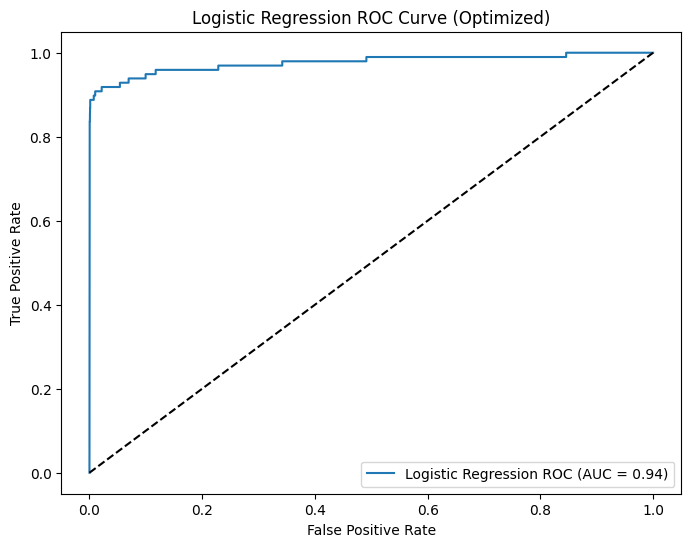

In [ ]:
# Cell 5: Train and Evaluate Logistic Regression (Optimized)

# Sample a subset of the SMOTE-balanced training data for hyperparameter tuning
X_train_smote_subset_scaled, y_train_smote_subset = resample(
    X_train_smote_scaled, y_train_smote,
    n_samples=int(0.2 * len(X_train_smote)),  # 20% of the data
    random_state=42
)

# Initialize Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Define a smaller parameter grid for tuning
lr_param_grid = {
    'C': [1],               # Fixed to a default value
    'solver': ['lbfgs']     # Fixed to a stable solver
}

# Perform grid search with reduced cross-validation folds
lr_grid = GridSearchCV(
    lr_model,
    lr_param_grid,
    cv=2,              # Reduced to 2 folds
    scoring='recall',
    n_jobs=-1
)
start_time = time.time()
lr_grid.fit(X_train_smote_subset_scaled, y_train_smote_subset)
tuning_time = time.time() - start_time

# Best Logistic Regression model from tuning
lr_best = lr_grid.best_estimator_

# Train the best model on the full SMOTE-balanced training data
start_time = time.time()
lr_best.fit(X_train_smote_scaled, y_train_smote)
lr_training_time = time.time() - start_time

# Predict on the test set
y_pred_lr = lr_best.predict(X_test_scaled)

# Evaluate performance
print("\nLogistic Regression Performance (Optimized):")
print(classification_report(y_test, y_pred_lr))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_lr))
print(f"Tuning Time (on subset): {tuning_time:.2f} seconds")
print(f"Final Training Time (on full data): {lr_training_time:.2f} seconds")

# Measure inference time
start_time = time.time()
y_pred_lr = lr_best.predict(X_test_scaled)
lr_inference_time = (time.time() - start_time) / len(X_test) * 1000  # ms per prediction
print(f"Inference Time per Transaction: {lr_inference_time:.4f} ms")

# Plot ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_best.predict_proba(X_test_scaled)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression ROC (AUC = {roc_auc_score(y_test, y_pred_lr):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve (Optimized)')
plt.legend()
plt.savefig('lr_roc_curve_optimized.png')
plt.show()


Ensemble Model Performance (Optimized):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.38      0.90      0.54        98

    accuracy                           1.00     56962
   macro avg       0.69      0.95      0.77     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9477309987022384
Training Time: 305.95 seconds
Inference Time per Transaction: 0.0076 ms


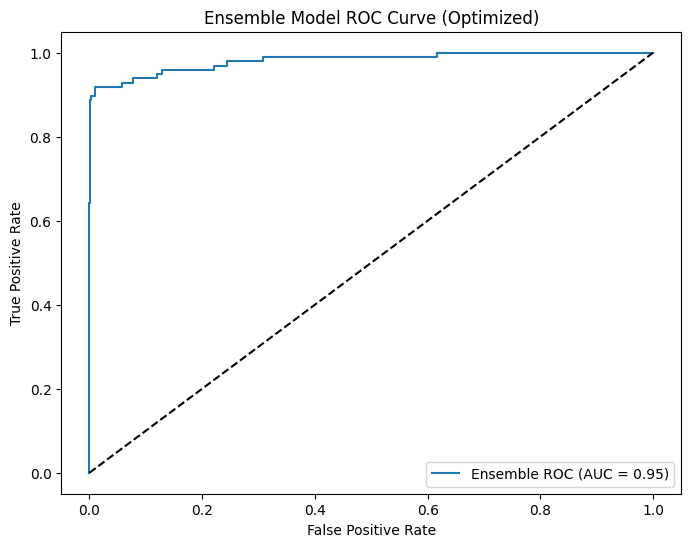

In [ ]:
# Cell 6: Create Ensemble Model (Optimized)

# Sample a subset of the SMOTE-balanced training data for ensemble tuning (optional)
# For simplicity, we'll train the ensemble directly on the full data after individual model training
# Subset can be added if tuning ensemble weights is needed later

# Combine models using a voting classifier (soft voting for probabilities)
ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf_best),
        ('xgb', xgb_best),
        ('lr', lr_best)
    ],
    voting='soft'
)

# Train ensemble model on the full SMOTE-balanced training data
start_time = time.time()
ensemble_model.fit(X_train_smote_scaled, y_train_smote)
ensemble_training_time = time.time() - start_time

# Predict and evaluate
y_pred_ensemble = ensemble_model.predict(X_test_scaled)
print("\nEnsemble Model Performance (Optimized):")
print(classification_report(y_test, y_pred_ensemble))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_ensemble))
print(f"Training Time: {ensemble_training_time:.2f} seconds")

# Measure inference time
start_time = time.time()
y_pred_ensemble = ensemble_model.predict(X_test_scaled)
ensemble_inference_time = (time.time() - start_time) / len(X_test) * 1000  # ms per prediction
print(f"Inference Time per Transaction: {ensemble_inference_time:.4f} ms")

# Plot ROC curve
fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test, ensemble_model.predict_proba(X_test_scaled)[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr_ensemble, tpr_ensemble, label=f'Ensemble ROC (AUC = {roc_auc_score(y_test, y_pred_ensemble):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble Model ROC Curve (Optimized)')
plt.legend()
plt.savefig('ensemble_roc_curve_optimized.png')
plt.show()

# Save ensemble model
with open('ensemble_model_optimized.pkl', 'wb') as f:
    pickle.dump(ensemble_model, f)

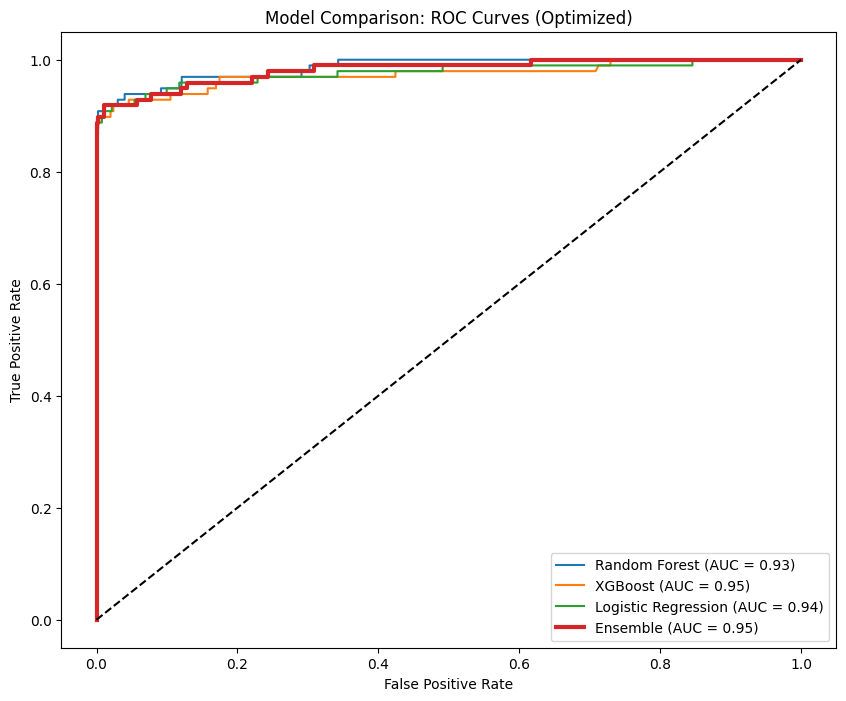

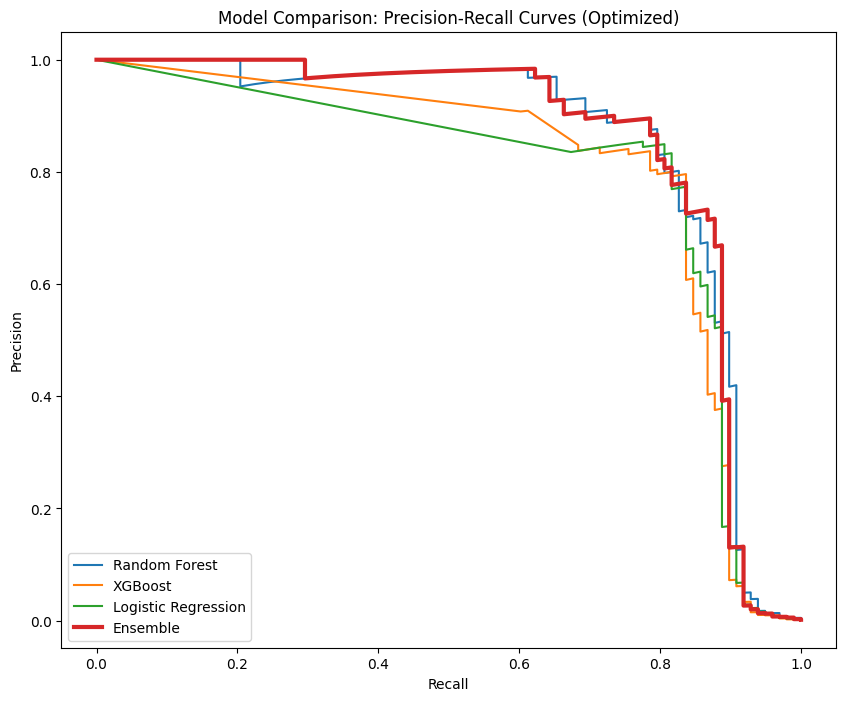

In [ ]:
# Cell 7: Compare Models

# Plot combined ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_rf):.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_pred_xgb):.2f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_lr):.2f})')
plt.plot(fpr_ensemble, tpr_ensemble, label=f'Ensemble (AUC = {roc_auc_score(y_test, y_pred_ensemble):.2f})', linewidth=3)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model Comparison: ROC Curves (Optimized)')
plt.legend()
plt.savefig('model_comparison_roc_optimized.png')
plt.show()

# Plot precision-recall curves
plt.figure(figsize=(10, 8))
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_best.predict_proba(X_test)[:, 1])
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_best.predict_proba(X_test)[:, 1])
precision_lr, recall_lr, _ = precision_recall_curve(y_test, lr_best.predict_proba(X_test_scaled)[:, 1])
precision_ensemble, recall_ensemble, _ = precision_recall_curve(y_test, ensemble_model.predict_proba(X_test_scaled)[:, 1])
plt.plot(recall_rf, precision_rf, label='Random Forest')
plt.plot(recall_xgb, precision_xgb, label='XGBoost')
plt.plot(recall_lr, precision_lr, label='Logistic Regression')
plt.plot(recall_ensemble, precision_ensemble, label='Ensemble', linewidth=3)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Model Comparison: Precision-Recall Curves (Optimized)')
plt.legend()
plt.savefig('model_comparison_pr_optimized.png')
plt.show()

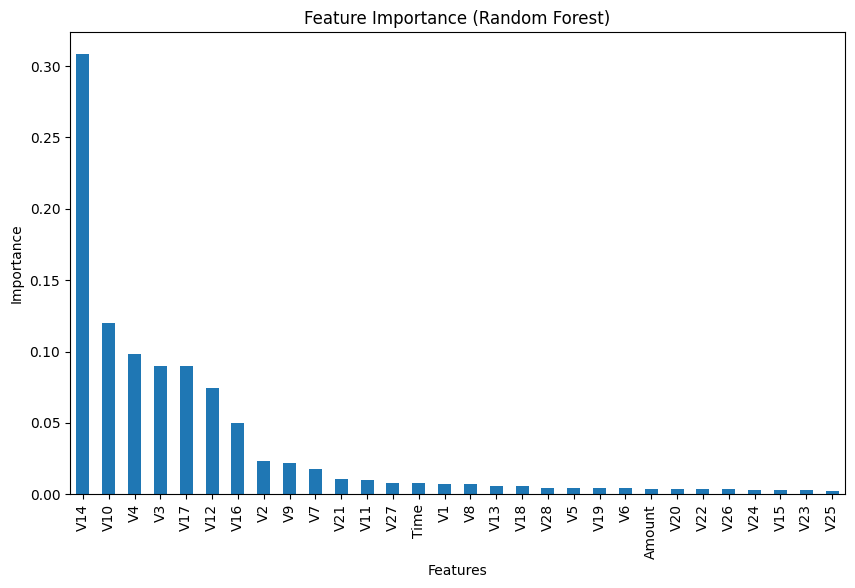


Ensemble with Selected Features Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.34      0.90      0.50        98

    accuracy                           1.00     56962
   macro avg       0.67      0.95      0.75     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.947502383057894
Training Time with Selected Features: 181.11 seconds
Inference Time per Transaction (Selected Features): 0.0055 ms


In [ ]:
# Cell 8: Feature Selection (Corrected)

# Feature importance from Random Forest (trained on full SMOTE-balanced data)
feature_importance = pd.Series(rf_best.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False, inplace=True)

# Plot feature importance
plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.savefig('feature_importance_optimized.png')
plt.show()

# Select top 15 features from the SMOTE-balanced training data
top_features = feature_importance.head(15).index
X_train_smote_selected = X_train_smote[top_features]  # Use X_train_smote, not X_train
X_test_selected = X_test[top_features]

# Fit a new scaler on the selected features from the SMOTE-balanced data
scaler_selected = StandardScaler()
X_train_selected_scaled = scaler_selected.fit_transform(X_train_smote_selected)
X_test_selected_scaled = scaler_selected.transform(X_test_selected)

# Save the new scaler for production use with selected features
with open('scaler_selected.pkl', 'wb') as f:
    pickle.dump(scaler_selected, f)

# Retrain ensemble with selected features
# Use the same hyperparameters as the original models, avoiding duplicate tree_method
ensemble_model_selected = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(**rf_best.get_params())),
        ('xgb', XGBClassifier(**xgb_best.get_params())),  # Remove explicit tree_method
        ('lr', LogisticRegression(**lr_best.get_params()))
    ],
    voting='soft'
)
start_time = time.time()
ensemble_model_selected.fit(X_train_selected_scaled, y_train_smote)  # Now matches in size
ensemble_training_time = time.time() - start_time

# Predict and evaluate
y_pred_selected = ensemble_model_selected.predict(X_test_selected_scaled)
print("\nEnsemble with Selected Features Performance:")
print(classification_report(y_test, y_pred_selected))
print("AUC-ROC:", roc_auc_score(y_test, y_pred_selected))
print(f"Training Time with Selected Features: {ensemble_training_time:.2f} seconds")

# Measure inference time
start_time = time.time()
y_pred_selected = ensemble_model_selected.predict(X_test_selected_scaled)
ensemble_inference_time = (time.time() - start_time) / len(X_test) * 1000  # ms per prediction
print(f"Inference Time per Transaction (Selected Features): {ensemble_inference_time:.4f} ms")

# Save the new ensemble model
with open('ensemble_model_selected.pkl', 'wb') as f:
    pickle.dump(ensemble_model_selected, f)

In [ ]:
# Cell 9: Model Quantization with ONNX

# Import necessary libraries (ensure these were installed in Cell 1)
import onnx
from onnxmltools.convert import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import numpy as np

# Convert RandomForestClassifier to ONNX
initial_type_rf = [('float_input', FloatTensorType([None, X_train_smote_selected.shape[1]]))]
onnx_model_rf = convert_sklearn(rf_best, initial_types=initial_type_rf)
onnx.save_model(onnx_model_rf, 'optimized_rf_onnx.onnx')
print("Random Forest model converted to ONNX")

# Convert LogisticRegression to ONNX
initial_type_lr = [('float_input', FloatTensorType([None, X_train_smote_selected.shape[1]]))]
onnx_model_lr = convert_sklearn(lr_best, initial_types=initial_type_lr)
onnx.save_model(onnx_model_lr, 'optimized_lr_onnx.onnx')
print("Logistic Regression model converted to ONNX")

# Note: XGBoost is not converted due to skl2onnx limitations
print("Note: XGBoost is excluded from ONNX conversion due to skl2onnx limitations. Use Python-based ensemble for full model.")

Random Forest model converted to ONNX
Logistic Regression model converted to ONNX
Note: XGBoost is excluded from ONNX conversion due to skl2onnx limitations. Use Python-based ensemble for full model.
